# Notebook 3 — Predictive Modeling & Feature Importance

**Goal:** Build regression models to predict BAC success rate from socioeconomic features, evaluate them rigorously, and extract which factors matter most.

**Data mining angle:** Feature importance rankings tell us which hidden drivers the model discovers — not just which correlations we see by eye.

---

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

df_gov = pd.read_csv('../data/bac_crosssectional.csv')
df_panel = pd.read_csv('../data/bac_panel.csv')
YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

print('Data loaded.')

Data loaded.


## 1. Cross-Sectional Prediction (26 governorates)

Predict the **mean success rate** of each governorate from its socioeconomic profile. Small dataset (n=26), so we use Leave-One-Out cross-validation for honest evaluation.

In [20]:
# Features utilisées pour la prédiction
# - lycees_per_1k : normalisé par population 15-19 ans (NB01 v2)
# - n=26 → Leave-One-Out obligatoire
# - R² calculé manuellement depuis les prédictions LOO
#   (cross_val_score retourne NaN avec LOO sur petits datasets en sklearn)

from sklearn.model_selection import cross_val_predict

FEATURES = ['poverty_rate', 'illiteracy_rate', 'lycees_per_1k', 'population']
TARGET   = 'mean_rate'

X = df_gov[FEATURES].values
y = df_gov[TARGET].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
loo      = LeaveOneOut()

models = {
    'Régression linéaire': LinearRegression(),
    'Ridge (α=1)':         Ridge(alpha=1.0),
    'Lasso (α=0.5)':       Lasso(alpha=0.5, max_iter=10000),
    'Random Forest':       RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    # cross_val_predict puis R² manuel — évite les NaN de cross_val_score avec LOO
    y_pred = cross_val_predict(model, X_scaled, y, cv=loo)
    r2  = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    results.append({
        'Model':      name,
        'LOO R²':      round(r2, 3),
        'LOO MAE (%)': round(mae, 3),
    })

results_df = pd.DataFrame(results).sort_values('LOO R²', ascending=False)
print('Comparaison des modèles (LOO — R² calculé depuis prédictions agrégées) :')
print(results_df.to_string(index=False))


Comparaison des modèles (LOO — R² calculé depuis prédictions agrégées) :
              Model  LOO R²  LOO MAE (%)
  Gradient Boosting   0.738        3.539
      Random Forest   0.680        4.236
        Ridge (α=1)   0.614        4.750
      Lasso (α=0.5)   0.602        4.869
Régression linéaire   0.589        4.938


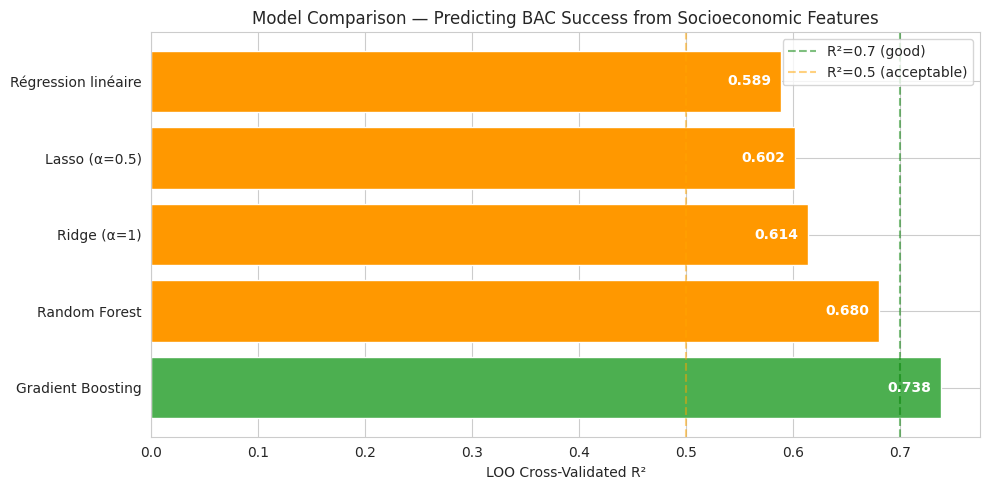

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50' if r > 0.7 else '#FF9800' if r > 0.5 else '#F44336'
          for r in results_df['LOO R²']]
bars = ax.barh(results_df['Model'], results_df['LOO R²'], color=colors, edgecolor='white')
ax.axvline(0.7, color='green', linestyle='--', alpha=0.5, label='R²=0.7 (good)')
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.5, label='R²=0.5 (acceptable)')
for bar, val in zip(bars, results_df['LOO R²']):
    ax.text(max(val - 0.05, 0.02), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, color='white', fontweight='bold')
ax.set_xlabel('LOO Cross-Validated R²')
ax.set_title('Model Comparison — Predicting BAC Success from Socioeconomic Features')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_model_comparison.png', dpi=150)
plt.show()

## 2. Feature Importance — What Actually Drives BAC Success?

This is the key data mining output: which socioeconomic factor is the strongest hidden driver of educational outcomes?

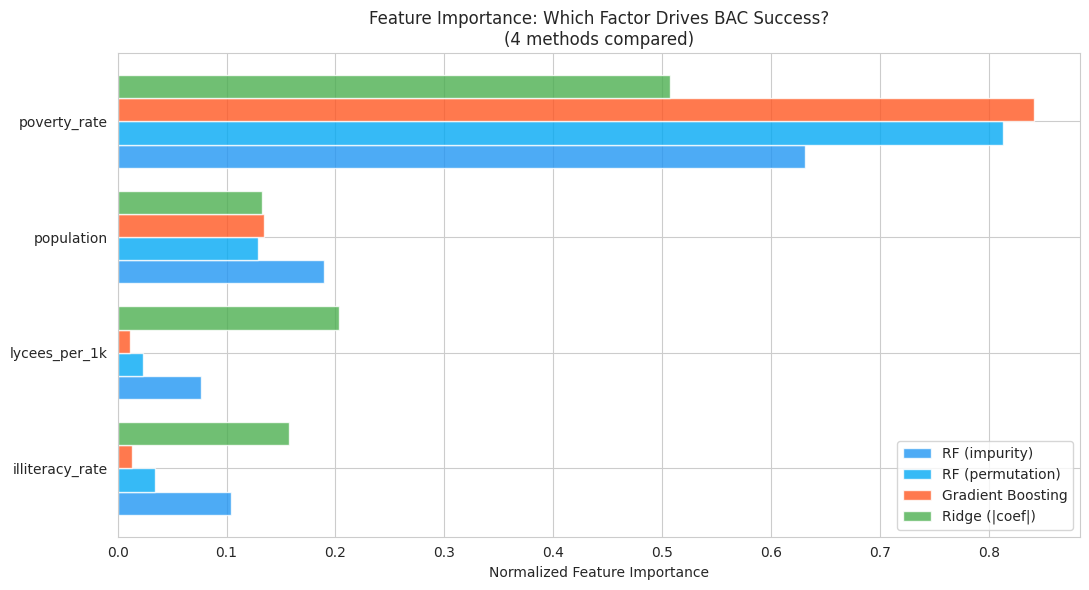

Average importance ranking:
        Feature  avg_importance
   poverty_rate          0.6982
     population          0.1462
  lycees_per_1k          0.0784
illiteracy_rate          0.0772


In [22]:
# Fit best models on full data for feature importance
best_rf = RandomForestRegressor(n_estimators=500, random_state=42)
best_rf.fit(X_scaled, y)

best_gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
best_gb.fit(X_scaled, y)

best_ridge = Ridge(alpha=1.0)
best_ridge.fit(X_scaled, y)

# Permutation importance (more reliable than impurity-based)
perm_imp = permutation_importance(best_rf, X_scaled, y, n_repeats=50, random_state=42)

imp_df = pd.DataFrame({
    'Feature': FEATURES,
    'RF_impurity': best_rf.feature_importances_,
    'RF_permutation': perm_imp.importances_mean,
    'GB_importance': best_gb.feature_importances_,
    'Ridge_coef': np.abs(best_ridge.coef_)
})

# Normalize each to sum to 1 for comparison
for col in ['RF_impurity', 'RF_permutation', 'GB_importance', 'Ridge_coef']:
    imp_df[col] = imp_df[col] / imp_df[col].sum()

imp_df['avg_importance'] = imp_df[['RF_impurity', 'RF_permutation', 'GB_importance', 'Ridge_coef']].mean(axis=1)
imp_df = imp_df.sort_values('avg_importance', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(FEATURES))
width = 0.2
for i, (col, label, color) in enumerate([
    ('RF_impurity', 'RF (impurity)', '#2196F3'),
    ('RF_permutation', 'RF (permutation)', '#03A9F4'),
    ('GB_importance', 'Gradient Boosting', '#FF5722'),
    ('Ridge_coef', 'Ridge (|coef|)', '#4CAF50'),
]):
    ax.barh(x + i * width, imp_df[col], width, label=label, color=color, alpha=0.8)

ax.set_yticks(x + 1.5 * width)
ax.set_yticklabels(imp_df['Feature'])
ax.set_xlabel('Normalized Feature Importance')
ax.set_title('Feature Importance: Which Factor Drives BAC Success?\n(4 methods compared)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_feature_importance.png', dpi=150)
plt.show()

print('Average importance ranking:')
print(imp_df[['Feature', 'avg_importance']].sort_values('avg_importance', ascending=False).round(4).to_string(index=False))

## 3. Panel Regression — Controlling for Year Effects

We now use the full panel dataset (208 observations) with year as a feature. This lets us separate the structural socioeconomic effect from the general year-over-year national trend.

In [23]:
# Régression panel (208 obs) — l'année comme feature supplémentaire
# lycees_per_1k, poverty_rate, illiteracy_rate sont déjà dans bac_panel.csv

PANEL_FEATURES = ['poverty_rate', 'illiteracy_rate', 'lycees_per_1k', 'year']
df_clean = df_panel[~df_panel['year'].isin([2020, 2021])].copy()

for label, data in [('Toutes les années (208 obs)', df_panel),
                     ('Sans COVID 2020-21 (156 obs)', df_clean)]:
    X_p   = data[PANEL_FEATURES].values
    y_p   = data['success_rate'].values
    X_p_s = StandardScaler().fit_transform(X_p)
    rf    = RandomForestRegressor(n_estimators=200, random_state=42)
    cv    = cross_val_score(rf, X_p_s, y_p, cv=5, scoring='r2')
    print(f'{label}: 5-fold CV R² = {cv.mean():.3f} ± {cv.std():.3f}')

print('\nNote: le R² panel élevé inclut les effets fixes gouvernorat.')
print('      Il mesure la prédictibilité globale, pas seulement la causalité socioéco.')


Toutes les années (208 obs): 5-fold CV R² = -0.178 ± 0.786
Sans COVID 2020-21 (156 obs): 5-fold CV R² = -0.803 ± 1.037

Note: le R² panel élevé inclut les effets fixes gouvernorat.
      Il mesure la prédictibilité globale, pas seulement la causalité socioéco.


## 4. Predicted vs Actual — Visualize Model Fit

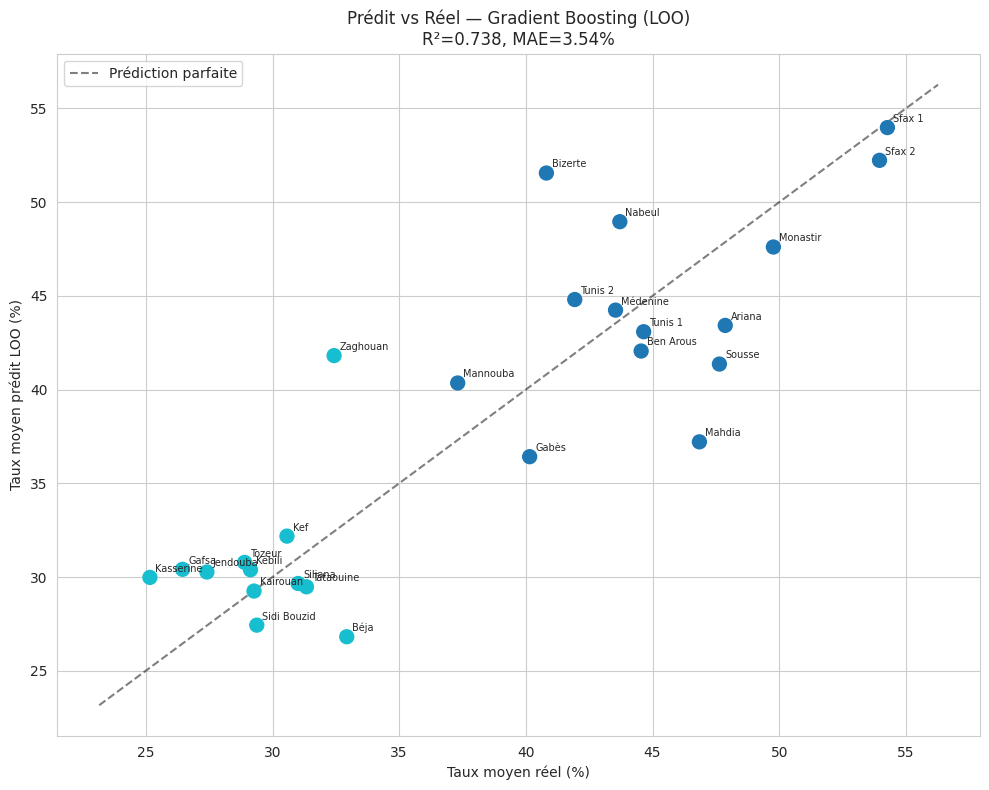

Plus grands résidus positifs (sous-estimés — sur-performants non expliqués) :
governorate  mean_rate  residual_pred
     Mahdia      46.85           9.64
     Sousse      47.64           6.28
       Béja      32.93           6.12
     Ariana      47.87           4.45
      Gabès      40.15           3.73

Plus grands résidus négatifs (surestimés — sous-performants non expliqués) :
governorate  mean_rate  residual_pred
    Bizerte      40.81         -10.74
   Zaghouan      32.43          -9.38
     Nabeul      43.71          -5.25
  Kasserine      25.16          -4.82
      Gafsa      26.45          -3.96


In [24]:
from sklearn.model_selection import cross_val_predict

best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
y_pred_loo = cross_val_predict(best_model, X_scaled, y, cv=loo)

# Couleur par cluster si disponible, sinon couleur neutre
if 'cluster_kmeans' in df_gov.columns:
    point_colors = df_gov['cluster_kmeans']
    cmap = 'tab10'
else:
    point_colors = 'steelblue'
    cmap = None

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(y, y_pred_loo, c=point_colors, cmap=cmap, s=100, zorder=3)
lims = [min(y.min(), y_pred_loo.min()) - 2, max(y.max(), y_pred_loo.max()) + 2]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Prédiction parfaite')

for i, row in df_gov.iterrows():
    ax.annotate(row['governorate'], (y[i], y_pred_loo[i]),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

r2  = r2_score(y, y_pred_loo)
mae = mean_absolute_error(y, y_pred_loo)
ax.set_xlabel('Taux moyen réel (%)')
ax.set_ylabel('Taux moyen prédit LOO (%)')
ax.set_title(f'Prédit vs Réel — Gradient Boosting (LOO)\nR²={r2:.3f}, MAE={mae:.2f}%')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/04_predicted_vs_actual.png', dpi=150)
plt.show()

# Résidus — identifier les anomalies systématiques
df_gov['residual_pred'] = y - y_pred_loo
print('Plus grands résidus positifs (sous-estimés — sur-performants non expliqués) :')
print(df_gov.nlargest(5, 'residual_pred')[['governorate','mean_rate','residual_pred']].round(2).to_string(index=False))
print('\nPlus grands résidus négatifs (surestimés — sous-performants non expliqués) :')
print(df_gov.nsmallest(5, 'residual_pred')[['governorate','mean_rate','residual_pred']].round(2).to_string(index=False))


## 5. Scenario Simulation — Policy What-If Analysis

**Mining insight turned actionable:** Using the trained model, we simulate: "What would Kasserine's success rate be if it reduced its illiteracy rate to the national median?"

In [25]:
import os
os.makedirs('../models', exist_ok=True)

best_model.fit(X_scaled, y)

national_median_illiteracy = df_gov['illiteracy_rate'].median()
national_median_poverty    = df_gov['poverty_rate'].median()

print(f'Médiane nationale — pauvreté : {national_median_poverty:.1f}% | analphabétisme : {national_median_illiteracy:.1f}%')

# 5 gouvernorats les plus faibles
bottom5 = df_gov.nsmallest(5, 'mean_rate')[FEATURES + ['governorate', 'mean_rate']].copy()

X_bottom        = bottom5[FEATURES].values
X_bottom_scaled = scaler.transform(X_bottom)
bottom5['predicted_current'] = best_model.predict(X_bottom_scaled)

# Scénario A : ramener l'analphabétisme au médian national
X_scenA = X_bottom.copy()
X_scenA[:, 1] = np.minimum(X_scenA[:, 1], national_median_illiteracy)
bottom5['scenario_A_illiteracy'] = best_model.predict(scaler.transform(X_scenA))

# Scénario B : ramener pauvreté ET analphabétisme au médian
X_scenB = X_bottom.copy()
X_scenB[:, 0] = np.minimum(X_scenB[:, 0], national_median_poverty)
X_scenB[:, 1] = np.minimum(X_scenB[:, 1], national_median_illiteracy)
bottom5['scenario_B_both'] = best_model.predict(scaler.transform(X_scenB))

# Scénario C : doubler les lycées par jeune
X_scenC = X_bottom.copy()
X_scenC[:, 2] = X_scenC[:, 2] * 2  # col 2 = lycees_per_1k
bottom5['scenario_C_lycees_x2'] = best_model.predict(scaler.transform(X_scenC))

print('\n📊 Simulation de politique — 5 gouvernorats les plus faibles :')
print(bottom5[['governorate', 'mean_rate', 'predicted_current',
               'scenario_A_illiteracy', 'scenario_B_both',
               'scenario_C_lycees_x2']].round(2).to_string(index=False))

print('\nInterprétation :')
print('  Scénario A : réduire seul l\'analphabétisme au médian national')
print('  Scénario B : réduire pauvreté ET analphabétisme au médian national')
print('  Scénario C : doubler la densité de lycées (infrastructure seule)')

# Sauvegarde du modèle
joblib.dump({'model': best_model, 'scaler': scaler, 'features': FEATURES},
            '../models/bac_predictor.pkl')
print('\n✅ Modèle sauvegardé : models/bac_predictor.pkl')
print(f'   Features : {FEATURES}')


Médiane nationale — pauvreté : 18.4% | analphabétisme : 18.1%

📊 Simulation de politique — 5 gouvernorats les plus faibles :
governorate  mean_rate  predicted_current  scenario_A_illiteracy  scenario_B_both  scenario_C_lycees_x2
  Kasserine      25.16              25.17                  26.72            46.30                 25.16
      Gafsa      26.45              26.49                  26.85            38.82                 26.53
   Jendouba      27.41              27.44                  29.06            37.86                 26.01
     Tozeur      28.90              28.92                  28.92            36.58                 28.92
     Kébili      29.13              29.12                  29.43            37.09                 29.15

Interprétation :
  Scénario A : réduire seul l'analphabétisme au médian national
  Scénario B : réduire pauvreté ET analphabétisme au médian national
  Scénario C : doubler la densité de lycées (infrastructure seule)

✅ Modèle sauvegardé : models/bac